In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

## Part a

## Rolling Buy and Hold Analysis

#### 1.	Choose and justify an appropriate shock definition/metric for this series.


=== 1-month horizon ===
Observations: 12603
  Entire histogram (all rolling returns) (n=12603):
    mean=0.008030  median=0.011533  skew=-0.738827  kurtosis(excess)=4.497664
Left-tail return quantiles (worst→best; ~99% / 95% / 90% loss levels):
  p1:  -0.1160 (-11.60%)  loss_mag: 0.1160
  p5:  -0.0651 (-6.51%)  loss_mag: 0.0651
  p10: -0.0437 (-4.37%)  loss_mag: 0.0437
Right-tail return quantiles (~90% / 95% / 99% gain levels):
  p90: 0.0553 (+5.53%)  gain_mag: 0.0553
  p95: 0.0711 (+7.11%)  gain_mag: 0.0711
  p99: 0.1135 (+11.35%)  gain_mag: 0.1135
Best / worst single-period return:
  Worst: -0.3167  Best: 0.2661

=== 3-month horizon ===
Observations: 12603
  Entire histogram (all rolling returns) (n=12603):
    mean=0.024117  median=0.029003  skew=-0.541327  kurtosis(excess)=2.688787
Left-tail return quantiles (worst→best; ~99% / 95% / 90% loss levels):
  p1:  -0.2117 (-21.17%)  loss_mag: 0.2117
  p5:  -0.1020 (-10.20%)  loss_mag: 0.1020
  p10: -0.0648 (-6.48%)  loss_mag: 0.0648
Rig

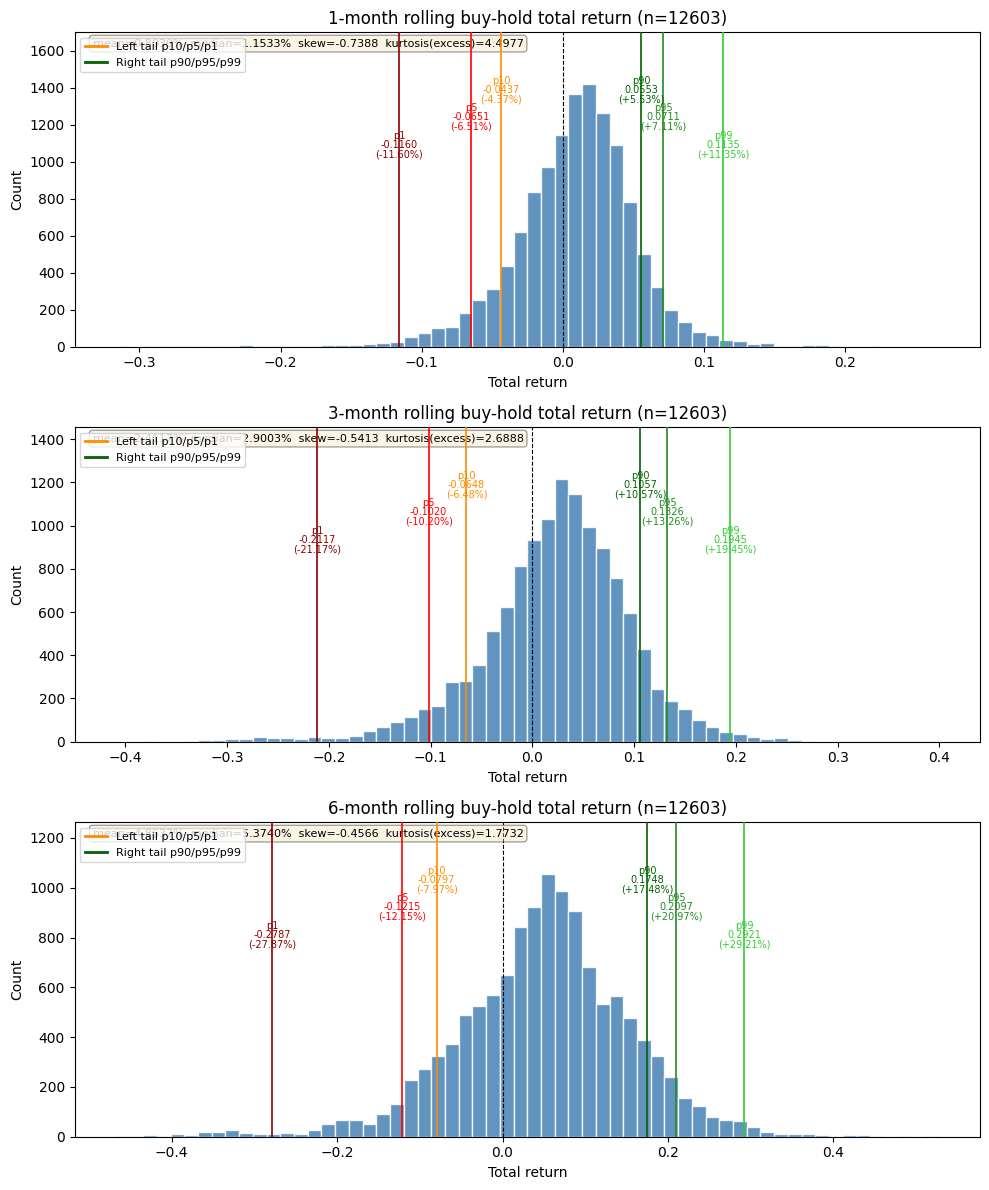

{'return_p1': -0.11601267569427189,
 'return_p5': -0.06511738096189126,
 'return_p10': -0.04369981368910305,
 'loss_magnitude_p99': 0.11601267569427189,
 'loss_magnitude_p95': 0.06511738096189126,
 'loss_magnitude_p90': 0.04369981368910305,
 'return_p90': 0.05529902757968329,
 'return_p95': 0.0711111161988406,
 'return_p99': 0.11346280066652063,
 'gain_magnitude_p90': 0.05529902757968329,
 'gain_magnitude_p95': 0.0711111161988406,
 'gain_magnitude_p99': 0.11346280066652063}

In [2]:
from spx_rolling_buyhold import analyze_spx_rolling, load_spx, rolling_calendar_month_returns, tail_loss_percentiles

out = analyze_spx_rolling()
out[1]["full_moments"]
#out[1]["right_tail_moments"]
out[1]["tail_metrics"]

## Drawdown Peak to Trough

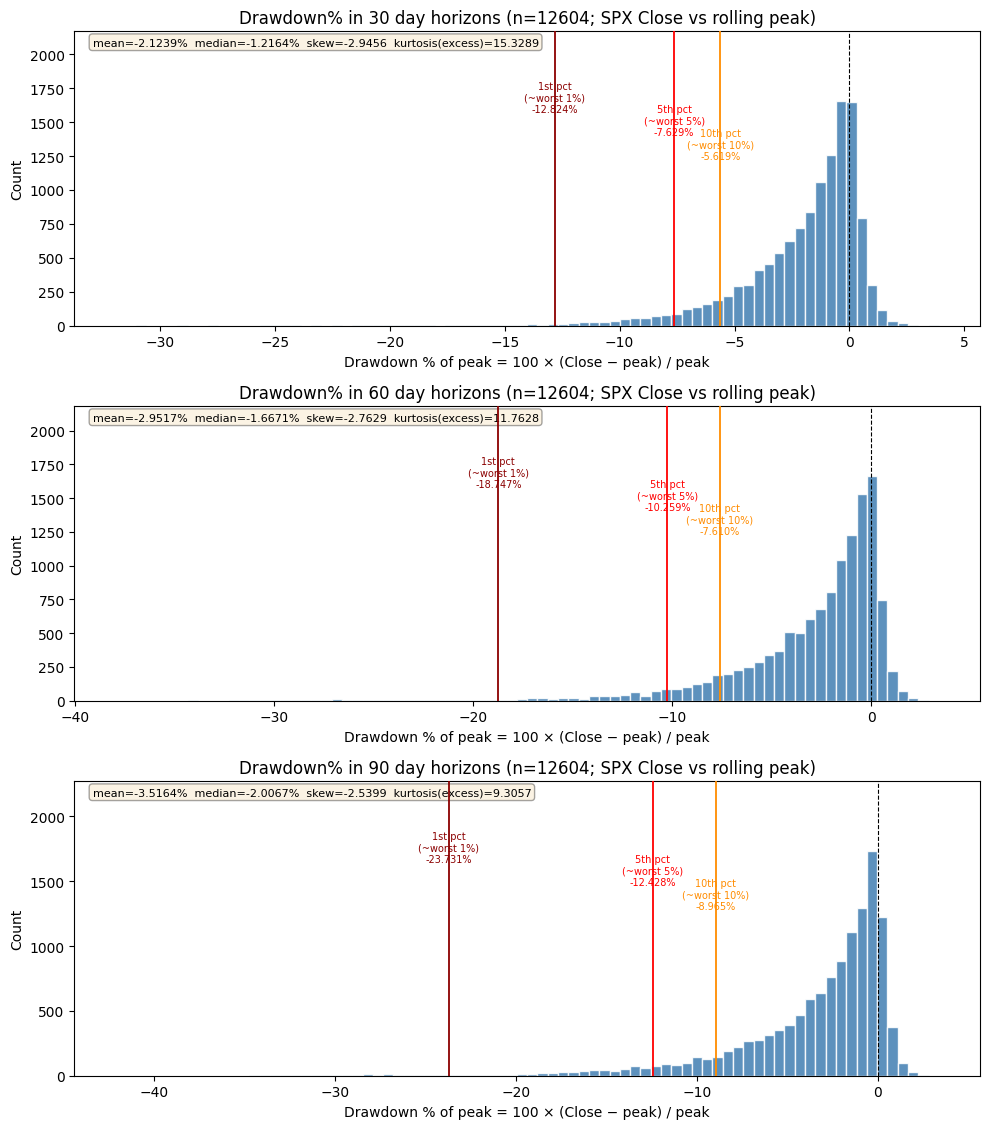

Worst-case tail: 1st / 5th / 10th pct of drawdown/peak (more negative = worse); ~99% / 95% / 90% of days are less severe. Moments on same series (fraction; ×100 = %).
  30-day: n=12604  p1=-12.824%  p5=-7.629%  p10=-5.619%  |  mean=-2.1239%  median=-1.2164%  skew=-2.9456  kurtosis(excess)=15.3289
  60-day: n=12604  p1=-18.747%  p5=-10.259%  p10=-7.610%  |  mean=-2.9517%  median=-1.6671%  skew=-2.7629  kurtosis(excess)=11.7628
  90-day: n=12604  p1=-23.731%  p5=-12.428%  p10=-8.965%  |  mean=-3.5164%  median=-2.0067%  skew=-2.5399  kurtosis(excess)=9.3057


In [3]:
%matplotlib inline

from spx_drawdown_severity import analyze_spx_drawdown_percentiles

out = analyze_spx_drawdown_percentiles()

In [5]:
out[30]["moments"]

{'mean': -0.021239155440456826,
 'median': -0.012164039861657231,
 'skew': -2.9455518251049915,
 'kurtosis': 15.328943999823359,
 'n': 12604.0}

## Trading-day buy-and-hold (30 / 60 / 90 days)

Rolling **simple** returns \(P_{t}/P_{t-w}-1\). From daily **log** returns, the same value is `np.expm1(sum of w log returns)` (sanity line on historical plot).

Tail lines: **left** p10 / p5 / p1 (≈ 90% / 95% / 99% VaR-style worst outcomes); **right** p90 / p95 / p99 (same convention as `tail_loss_percentiles` in `spx_rolling_buyhold`).


In [ ]:
from spx_trading_day_buyhold import analyze_trading_day_buyhold_percentiles

td_out = analyze_trading_day_buyhold_percentiles(show_plots=True)
# Ranked table (worst → best): e.g. td_out[30]["returns_df"].head(10)
# Tail dict: td_out[30]["tail_metrics"]


### Part (b) simulated paths — same 30/60/90 trading-day simple returns

Uses bridged t-GARCH paths from `partb_sim` (pool many paths, then same histograms / tails).


In [ ]:
from partb import build_part_b_split, fit_t_garch_on_daily_recent, load_spx_daily
from spx_trading_day_buyhold import analyze_partb2_simulated_trading_buyhold

monthly_early_b, daily_recent_b, _ = build_part_b_split()
daily_full_b = load_spx_daily()
garch_b = fit_t_garch_on_daily_recent(daily_recent_b)

sim_td = analyze_partb2_simulated_trading_buyhold(
    monthly_early_b,
    daily_full_b,
    garch_b,
    n_paths=80,
    seed=42,
    show_plots=True,
)
